# Mutual Fund Analytics - Exploratory Data Analysis (EDA)

**Internship:** BlueStock Data Analytics Internship

## Objective

The objective of this notebook is to perform Exploratory Data Analysis (EDA) on the mutual fund datasets using Python visualization libraries such as Plotly and Seaborn. The analysis focuses on identifying trends, patterns, and insights related to NAV, AUM, SIP inflows, investor demographics, portfolio allocation, and fund performance.

In [2]:
import sys
print(sys.executable)

c:\Users\nisht\AppData\Local\Programs\Python\Python313\python.exe


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# Better looking charts
plt.style.use("ggplot")

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [4]:
import pandas as pd

# Load cleaned NAV dataset
nav = pd.read_csv("data/processed/nav_history_cleaned.csv")

# Display first 5 rows
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Check data types
print(nav.dtypes)

amfi_code             int64
date         datetime64[ns]
nav                 float64
dtype: object


In [6]:
import plotly.express as px

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)"
)

# Highlight Bull Run (2023)
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight Market Correction (2024)
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.show()

In [7]:
aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [8]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')


In [9]:
# Convert date to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Verify
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


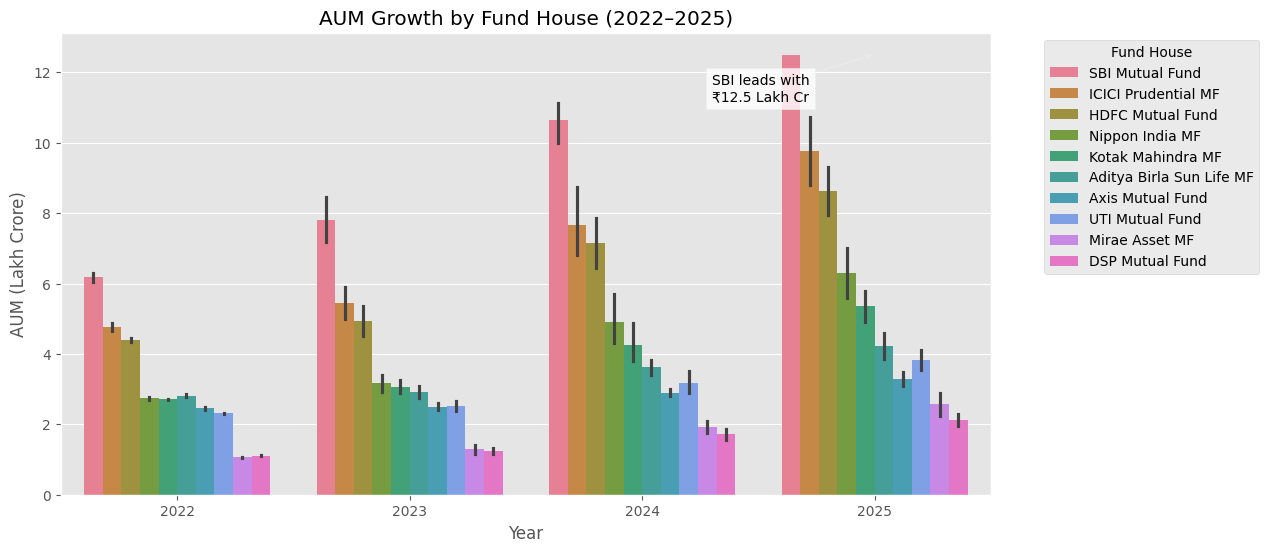

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)


# Highlight SBI's dominance

plt.annotate(
    "SBI leads with\n₹12.5 Lakh Cr",
    xy=(3, 12.5),
    xytext=(2.3, 11.2),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# Save chart as PNG
plt.savefig(
    "reports/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [12]:
print(sip.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')


In [13]:
sip.head(10)

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN
5,2022-06,12276,5.60,7.50,5.18,NaN
6,2022-07,12140,5.65,9.21,5.25,NaN
7,2022-08,12694,5.71,8.90,5.31,NaN
8,2022-09,12976,5.80,9.40,5.41,NaN
9,2022-10,13040,5.93,9.52,5.55,NaN


In [14]:
# Convert month column into datetime
sip["month"] = pd.to_datetime(sip["month"])

# Verify
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [15]:
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]
print(max_row)

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


In [16]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)",
    markers=True
)

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text="₹31,002 Cr<br>All-Time High",
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.show()

In [17]:
fig.write_image("reports/sip_inflow_trend.png")

TypeError: Type is not JSON serializable: Timestamp

In [ ]:
# Find row with highest SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

max_row

month                        2025-12
sip_inflow_crore               31002
active_sip_accounts_crore       9.35
new_sip_accounts_lakh            9.8
sip_aum_lakh_crore              15.9
yoy_growth_pct                 17.17
Name: 47, dtype: object

In [ ]:
print(max_row)

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


In [ ]:
fig.write_image("reports/sip_inflow_trend.png")

In [ ]:
import sys
print(sys.executable)

c:\Users\nisht\AppData\Local\Programs\Python\Python313\python.exe


In [ ]:
import plotly
print(plotly.__version__)

6.8.0


In [ ]:
category = pd.read_csv("data/raw/05_category_inflows.csv")
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [ ]:
print(category.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='object')


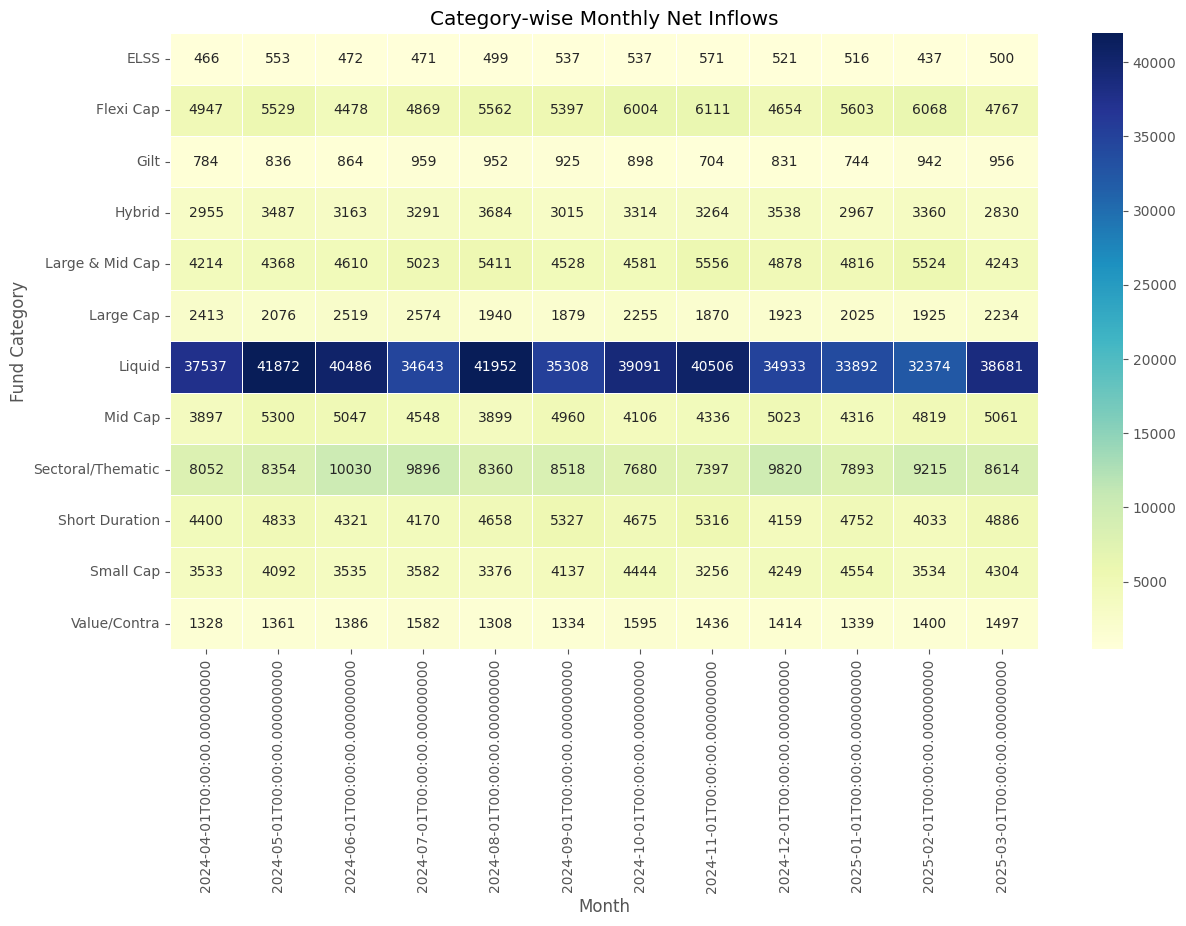

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert month to datetime
category["month"] = pd.to_datetime(category["month"])

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

# Plot heatmap
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Category-wise Monthly Net Inflows")
plt.xlabel("Month")
plt.ylabel("Fund Category")

# Save PNG
plt.savefig(
    "reports/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
folio = pd.read_csv("data/raw/06_industry_folio_count.csv")
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [21]:
print(folio.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')


In [ ]:
folio["month"] = pd.to_datetime(folio["month"])

In [22]:
folio["month"] = pd.to_datetime(folio["month"])

In [23]:
import plotly.express as px

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    title="Industry Folio Count Growth (2022–2025)",
    markers=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)"
)

fig.show()

In [24]:
fig.write_image("reports/industry_folio_growth.png")

In [25]:
max_row = folio.loc[folio["total_folios_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["total_folios_crore"],
    text=f'{max_row["total_folios_crore"]:.2f} Cr<br>Highest',
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.show()

In [33]:
fig.write_image("reports/industry_folio_growth.png")

In [26]:
portfolio = pd.read_csv("data/raw/09_portfolio_holdings.csv")
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [27]:
print(portfolio.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


In [28]:
top10 = portfolio.sort_values(
    by="weight_pct",
    ascending=False
).head(10)

top10

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
183,119092,INFY,Infosys Ltd,IT,38.18,1254.80,3939.80,2025-12-31
229,101207,SUNPHARMA,Sun Pharmaceutical Industries,Pharma,35.07,285.75,5455.74,2025-12-31
118,118632,BHARTIARTL,Bharti Airtel Ltd,Telecom,30.44,1574.52,6271.17,2025-12-31
245,102885,NTPC,NTPC Ltd,Utilities,28.95,994.90,4140.59,2025-12-31
276,148568,SBIN,State Bank of India,Banking,28.61,498.31,2893.58,2025-12-31
40,119599,GRASIM,Grasim Industries Ltd,Diversified,28.25,1461.32,1872.83,2025-12-31
64,100033,M&M,Mahindra & Mahindra Ltd,Automobile,26.07,511.03,3852.87,2025-12-31
44,100016,WIPRO,Wipro Ltd,IT,25.90,552.43,579.31,2025-12-31
289,148569,BHARTIARTL,Bharti Airtel Ltd,Telecom,25.53,832.15,5736.45,2025-12-31
102,120505,SUNPHARMA,Sun Pharmaceutical Industries,Pharma,23.46,598.91,6868.09,2025-12-31


In [29]:
import plotly.express as px

fig = px.bar(
    top10,
    x="stock_name",
    y="weight_pct",
    color="sector",
    title="Top 10 Portfolio Holdings by Weight (%)",
    text="weight_pct"
)

fig.update_traces(texttemplate="%{text:.2f}%", textposition="outside")

fig.update_layout(
    xaxis_title="Stock",
    yaxis_title="Portfolio Weight (%)"
)

fig.show()

In [30]:
fig.write_image("reports/top10_portfolio_holdings.png")

In [31]:
max_row = top10.loc[top10["weight_pct"].idxmax()]

fig.add_annotation(
    x=max_row["stock_name"],
    y=max_row["weight_pct"],
    text=f'{max_row["stock_name"]}<br>{max_row["weight_pct"]:.2f}%',
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.show()

In [32]:
fig.write_image("reports/top10_portfolio_holdings.png")

In [34]:
benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [35]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='object')


In [ ]:
benchmark["date"] = benchmark["date"].astype(str)

In [37]:
import plotly.express as px

fig = px.line(
    benchmark,
    x="date",
    y="close_value",
    color="index_name",
    title="Benchmark Indices Performance (2022–2025)",
    markers=False
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Closing Value",
    legend_title="Index"
)

fig.show()

In [40]:
max_row = benchmark.loc[benchmark["close_value"].idxmax()]

fig.add_annotation(
    x=max_row["date"].strftime("%Y-%m-%d"),
    y=max_row["close_value"],
    text=f'{max_row["index_name"]}<br>{max_row["close_value"]:.0f}',
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.show()
fig.write_image("reports/benchmark_indices_performance.png")

TypeError: Type is not JSON serializable: Timestamp

In [41]:
fig.write_image("reports/benchmark_indices_performance.png")

TypeError: Type is not JSON serializable: Timestamp